In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.pipeline import Pipeline
from src.models import LinearRegressionModel, RandomForestModel

sns.set_theme(style="whitegrid")

In [2]:
# Lineare Regression as Baseline
lr_model = LinearRegressionModel()
lr_pipeline = Pipeline(
    model=lr_model,
    data_path="../data/raw/train.csv",
    target_column="critical_temp"
)

lr_pipeline.run()
print(f"\nLinear Regression Results:")
for metric, value in lr_pipeline.metrics.items():
    print(f"  {metric.upper()}: {value:.4f}")

Loaded 21263 rows from train.csv
Data validation passed

Linear Regression Results:
  RMSE: 17.7097
  R2: 0.7303


### Baseline: Linear Regression

| Metric | Value |
|--------|-------|
| RMSE   | 17.71 K |
| R²     | 0.7303 |

The linear baseline explains ~73% of the variance in T_c. While 
reasonable for an untuned linear model, the RMSE of ~17.7 K indicates 
that the complex, non-linear relationships governing superconductivity 
are not fully captured by a linear approach.

In [3]:
# Random Forest as main model
rf_model = RandomForestModel()
rf_pipeline = Pipeline(
    model=rf_model,
    data_path="../data/raw/train.csv",
    target_column="critical_temp"
)

rf_pipeline.run()
print(f"\nRandom Forest Results:")
for metric, value in rf_pipeline.metrics.items():
    print(f"  {metric.upper()}: {value:.4f}")

Loaded 21263 rows from train.csv
Data validation passed

Random Forest Results:
  RMSE: 9.6568
  R2: 0.9198


### Main Model: Random Forest

| Metric | Value |
|--------|-------|
| RMSE   | 9.66 K |
| R²     | 0.9198 |

The Random Forest model significantly outperforms the linear baseline, 
reducing RMSE by ~45% and achieving R² > 0.92. This confirms the 
hypothesis from the EDA that the relationships between elemental 
properties and critical temperature are inherently non-linear. 
The remaining ~8% unexplained variance may arise from structural 
information (crystal structure, layer geometry) not captured by the 
current 81 compositional features.

Linear Regression:


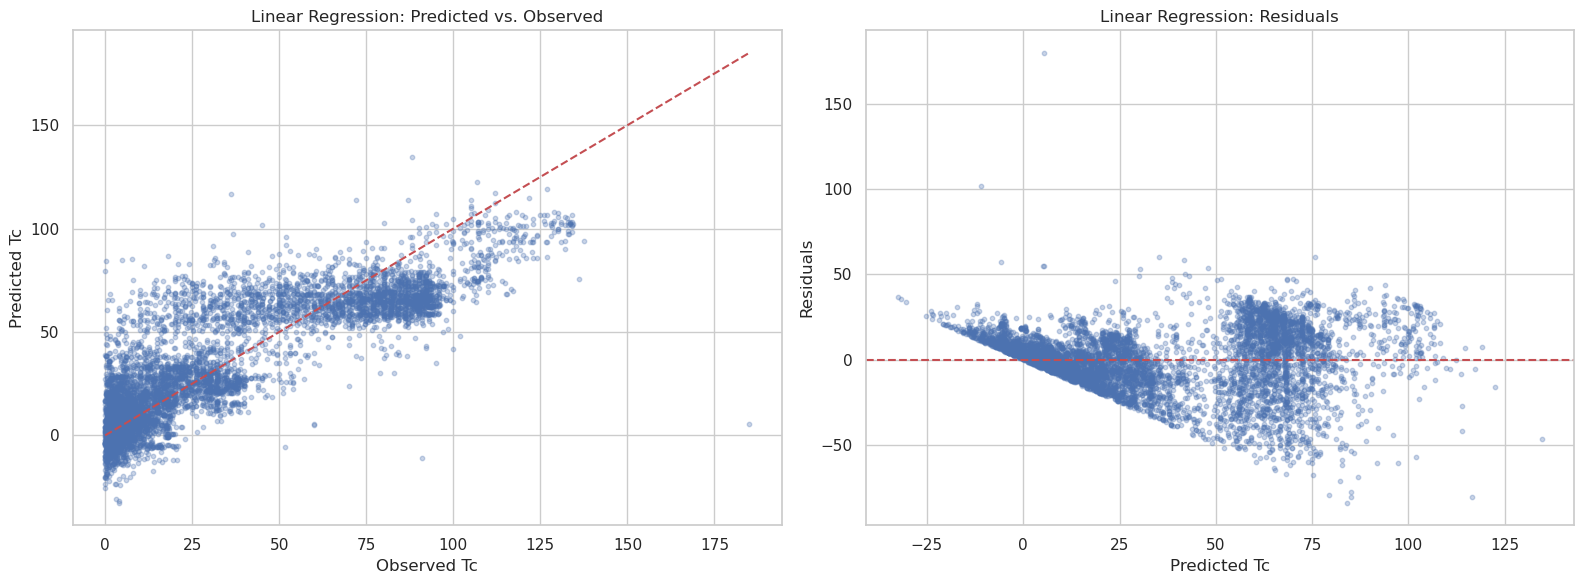

Random Forest:


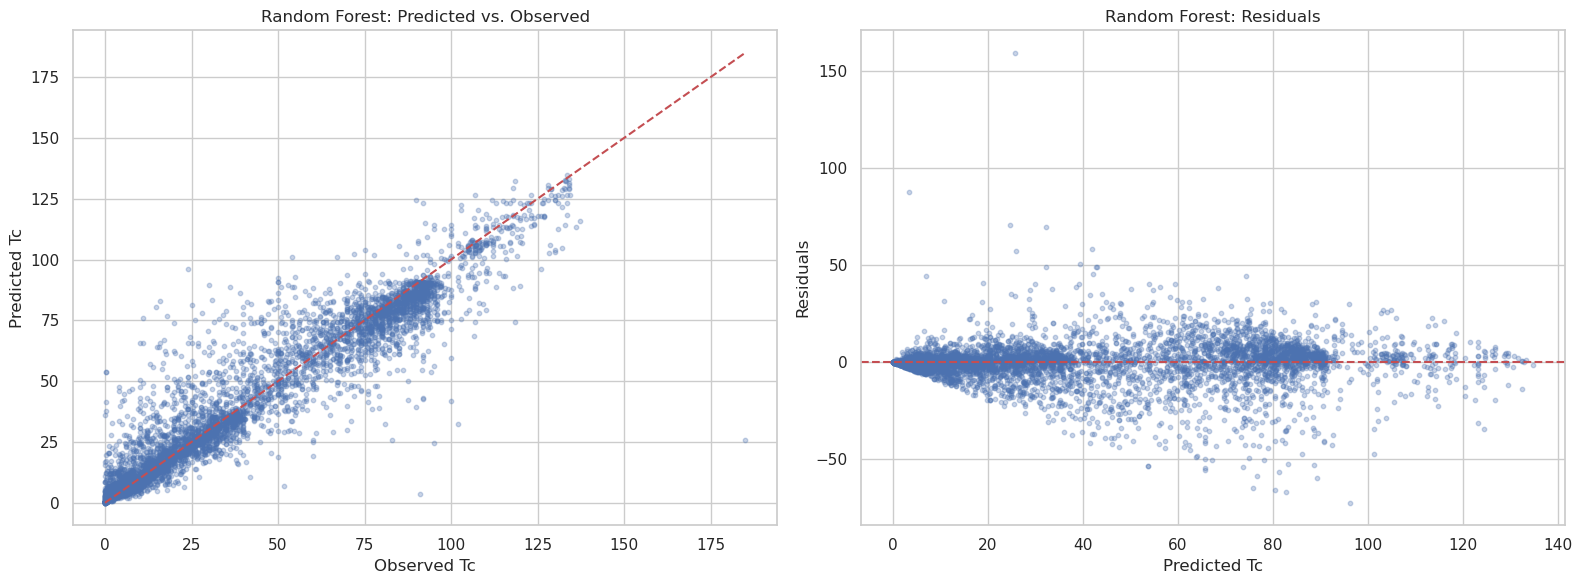

In [4]:
print("Linear Regression:")
lr_pipeline.plot_results()

print("Random Forest:")
rf_pipeline.plot_results()

### Model Comparison: Visual Analysis

#### Linear Regression (Baseline)
The predicted-vs-observed plot reveals systematic deviations from the 
diagonal. Below 25 K (observed), predictions are consistently too high, 
indicating that the linear model struggles with conventional 
superconductors. Between 50–80 K observed, a broad horizontal band 
appears, showing that the model produces similar predictions across 
a wide range of true temperatures — effectively smearing the 
non-linear transition zone. The residual plot exhibits a clear 
descending linear pattern, confirming systematic bias rather than 
random noise.

#### Random Forest (Main Model)
The predicted-vs-observed scatter closely follows the diagonal 
reference line across the entire T_c range (0–185 K). Residuals are 
approximately symmetrically distributed around zero with no 
discernible pattern, indicating that the model captures the 
underlying physical relationships without systematic over- or 
underprediction.

#### Conclusion
The visual comparison confirms the quantitative metrics: the Random 
Forest model successfully captures the non-linear, multi-modal 
relationships between elemental properties and critical temperature, 
while the linear baseline suffers from systematic bias inherent to 
its modeling assumptions.